# Bibliotecas fundamentais para Ciência de Dados

**Francisco Aparecido Rodrigues**<br>
Universidade de São Paulo, São Carlos, Brasil<br>
<https://sites.icmc.usp.br/francisco>

<hr>

Vamos estudar as principais bibliotecas utilizadas em Ciência de Dados com Python:

1. **Pandas** — manipulação e análise de dados tabulares;
2. **NumPy** — computação numérica com vetores e matrizes;
3. **SciPy** — funções científicas (estatística, otimização, integração, álgebra linear);
4. **Matplotlib** — visualização de dados.

Cada seção contém explicações teóricas curtas, exemplos práticos e **comentários em
todas as linhas de código relevantes**, para que você entenda não apenas o *que* o
código faz, mas também *por que* ele é usado.

> **Dica:** execute as células na ordem em que aparecem, pois algumas dependem de
> variáveis criadas anteriormente.

## 1 - Pandas

**Pandas** é a biblioteca mais usada em Python para manipulação e análise de
dados tabulares (parecidos com planilhas ou tabelas de banco de dados). Ela
introduz duas estruturas de dados principais:

- **Series**: um vetor unidimensional rotulado (como uma única coluna de uma planilha);
- **DataFrame**: uma tabela bidimensional, com linhas e colunas rotuladas (como a planilha inteira).

A imagem abaixo mostra a popularidade crescente do Pandas ao longo dos anos:

 <img src="https://storage.googleapis.com/lds-media/images/the-rise-in-popularity-of-pandas.width-1200.png" width="500"/>

A figura a seguir ilustra a diferença entre uma `Series` (uma coluna) e um
`DataFrame` (a tabela completa, composta por várias `Series`):

 <img src="https://storage.googleapis.com/lds-media/images/series-and-dataframe.width-1200.png" width="500" />

### 1.1 - Lendo e inspecionando dados

Vamos começar lendo um arquivo CSV (*Comma-Separated Values*), um dos formatos mais comuns para armazenar dados tabulares.

In [29]:
# Importa a biblioteca pandas com o apelido usual 'pd'
import pandas as pd  # pandas é usada para manipulação e análise de dados tabulares

# pd.read_csv le um arquivo CSV e devolve um DataFrame
#   - 'data/iris.csv'         : caminho do arquivo a ser lido
#   - header=0                : indica que a primeira linha do arquivo contém os nomes das colunas
#   - encoding="ISO-8859-1"   : define a codificação de caracteres do arquivo (evita erros com acentos)
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv', header=(0), encoding="ISO-8859-1")

# data.shape retorna uma tupla (numero_de_linhas, numero_de_colunas)
print("Número de linhas e colunas:", data.shape)

# data.head(10) mostra as 10 primeiras linhas do DataFrame (util para inspecao rapida)
data.head(20)

Número de linhas e colunas: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Podemos ainda visualizar o final da tabela, o que é útil para verificar se os dados foram carregados corretamente até a última linha:

In [30]:
# data.tail(10) mostra as 10 ultimas linhas do DataFrame
data.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,virginica
141,6.9,3.1,5.1,2.3,virginica
142,5.8,2.7,5.1,1.9,virginica
143,6.8,3.2,5.9,2.3,virginica
144,6.7,3.3,5.7,2.5,virginica
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


Também podemos acessar apenas algumas linhas usando a notação de *slicing* do Python:

In [31]:
# Usamos 'slicing' (fatiamento), assim como em listas, para pegar apenas as 5 primeiras linhas
# data[:5] equivale a "todas as linhas do inicio ate o indice 5 (exclusive)"
data[2:10]

,sepal_length,sepal_width,petal_length,petal_width,species
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Para acessar apenas uma coluna específica, basta informar o nome dela entre colchetes:

In [32]:
# Acessando uma unica coluna pelo nome: o resultado e uma Series (vetor rotulado)
data['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str

O Pandas também facilita a criação de gráficos simples diretamente a partir de uma coluna:

<Axes: >

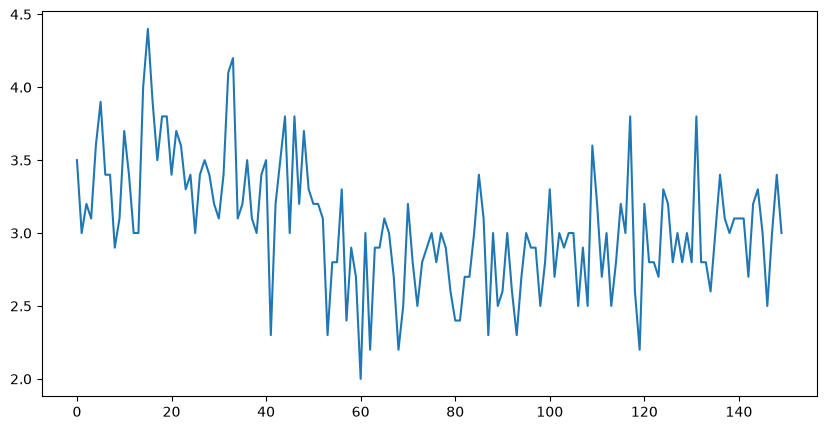

In [33]:
# O metodo .plot() das Series/DataFrames usa o Matplotlib por baixo dos panos
# figsize=(10, 5) define o tamanho da figura (largura, altura) 
data['sepal_width'].plot(figsize=(10, 5))

In [34]:
# data.info() mostra um resumo do DataFrame: numero de linhas, colunas,
# tipos de dados (dtype) de cada coluna e quantidade de valores nao-nulos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [35]:
# data.shape retorna novamente as dimensoes (linhas, colunas) do DataFrame
data.shape

(150, 5)

### 1.2 - Limpeza e organização dos dados

É comum que bases de dados reais contenham linhas duplicadas. Podemos removê-las facilmente:

In [36]:
# drop_duplicates() remove linhas totalmente duplicadas do DataFrame
data = data.drop_duplicates()

# Verificamos novamente as dimensoes para confirmar se alguma linha foi removida
data.shape

(147, 5)

Podemos renomear o nome dos atributos (colunas) para deixá-los mais legíveis ou traduzidos:

In [37]:
# data.columns retorna o Index (lista) com os nomes atuais das colunas
print(data.columns)
data.head()

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [38]:
# O metodo .rename() permite renomear colunas especificas usando um dicionario
#   - columns={...}   : mapeia {nome_antigo: nome_novo}
#   - inplace=True    : aplica a alteracao diretamente no DataFrame 'data' (sem precisar reatribuir)
data.rename(columns={
        'sepal_length': 'Comprimento da Sepala',
        'sepal_width': 'Largura da Sepala',
        'petal_length': 'Comprimento da Petala',
        'petal_width': 'Largura da Petala',
        'species': 'Especie',
    }, inplace=True)

print(data.columns)
data.head()

Index(['Comprimento da Sepala', 'Largura da Sepala', 'Comprimento da Petala',
       'Largura da Petala', 'Especie'],
      dtype='str')


,Comprimento da Sepala,Largura da Sepala,Comprimento da Petala,Largura da Petala,Especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Ou ainda, podemos substituir **todos** os nomes das colunas de uma só vez, atribuindo uma nova lista:

In [39]:
data.columns = ['Comp-Sepala', 'Largura-Sepala', 'Comp-petala', 'Largura-petala', 'Especie']
data.head()

,Comp-Sepala,Largura-Sepala,Comp-petala,Largura-petala,Especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Podemos também colocar o nome das colunas em minúsculo, usando uma *list comprehension*:

In [40]:
# 'for col in data' percorre os nomes das colunas do DataFrame
# col.lower() converte cada nome para minusculo
data.columns = [col.lower() for col in data]
data.head()

,comp-sepala,largura-sepala,comp-petala,largura-petala,especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 1.3 - Lendo dados diretamente de uma URL

O Pandas também consegue ler arquivos CSV hospedados na internet, sem a necessidade de baixá-los manualmente:

In [41]:
import pandas as pd

# pd.read_csv tambem aceita uma URL como caminho do arquivo
url = "https://raw.githubusercontent.com/cs109/2014_data/master/countries.csv"
data = pd.read_csv(url)

data.head(10)

,Country,Region
0,Algeria,AFRICA
1,Angola,AFRICA
2,Benin,AFRICA
3,Botswana,AFRICA
4,Burkina,AFRICA
5,Burundi,AFRICA
6,Cameroon,AFRICA
7,Cape Verde,AFRICA
8,Central African Republic,AFRICA
9,Chad,AFRICA


### 1.4 - Criando um DataFrame do zero

Além de ler arquivos, podemos criar um DataFrame diretamente a partir de um dicionário Python:

In [42]:
# Um dicionario onde cada chave vira uma coluna e cada valor (lista) vira os dados dessa coluna
data = {
    'apples': [3, 2, 0, 1],
    'oranges': [0, 3, 7, 2]
}

# pd.DataFrame converte o dicionario em uma tabela (DataFrame)
purchases = pd.DataFrame(data)
purchases.head()

,apples,oranges
0,3,0
1,2,3
2,0,7
3,1,2


In [43]:
import numpy as np  # usado aqui para gerar numeros aleatorios

# Lista de categorias (variavel categorica)
x1 = ['A', 'B', 'B', 'B', 'B', 'A', 'B', 'C', 'B', 'A']

# Vetores numericos gerados aleatoriamente a partir de uma distribuicao normal (media=0, desvio=1)
x2 = np.random.normal(0, 1, 10)
x3 = np.random.normal(0, 1, 10)

data = {
    'X1': x1,
    'X2': x2,
    'X3': x3
}

purchases = pd.DataFrame(data)
purchases.head(10)

,X1,X2,X3
0,A,-0.231715,-0.011297
1,B,-1.404316,-0.009625
2,B,0.255789,-1.193717
3,B,-0.032950,-0.085315
4,B,-0.372026,0.655947
5,A,-0.584879,1.177627
6,B,-2.448580,-1.548171
7,C,0.571874,-1.733016
8,B,-0.220752,-0.809133
9,A,-0.847323,-0.402451


Também podemos definir rótulos (índices) personalizados para as linhas, em vez de usar os números padrão (0, 1, 2, ...):

In [44]:
data = {
    'apples': [3, 2, 0, 1, 0],
    'oranges': [0, 3, 7, 2, 5]
}

# O parametro 'index' define os rotulos das linhas (aqui, nomes de pessoas)
# Note que 'Maria' aparece duas vezes: indices repetidos sao permitidos no Pandas
purchases = pd.DataFrame(data, index=['Maria', 'Luis', 'Carlos', 'Ana', 'Maria'])
purchases.head()

,apples,oranges
Maria,3,0
Luis,2,3
Carlos,0,7
Ana,1,2
Maria,0,5


Para localizar as linhas correspondentes a um índice específico, usamos `.loc[]`:

In [45]:
# .loc[] localiza linhas pelo ROTULO (label) do indice, e nao pela posicao
# Como existem duas linhas com indice 'Maria', o resultado tera as duas
purchases.loc['Maria']

,apples,oranges
Maria,3,0
Maria,0,5


### 1.5 - Salvando dados em arquivo

In [46]:
# to_csv() salva o DataFrame em um arquivo CSV no diretorio de trabalho atual
purchases.to_csv('new_data/new_purchases.csv')

### 1.6 - Identificando e tratando valores ausentes

In [47]:
import pandas as pd

url = "https://raw.githubusercontent.com/cs109/2014_data/master/countries.csv"
data = pd.read_csv(url)
data.head(10)

# isnull() retorna True/False para cada celula, indicando se o valor e nulo (NaN)
# .sum() soma esses valores (True=1, False=0) por coluna, contando quantos nulos existem em cada uma
data.isnull().sum()

Country    0
Region     0
dtype: int64

Podemos remover as colunas que contêm valores ausentes com `dropna`:

In [48]:
# dropna(axis=1) remove COLUNAS que contenham pelo menos um valor nulo
# (axis=0, o padrao, removeria LINHAS com valores nulos)
data.dropna(axis=1)

,Country,Region
0,Algeria,AFRICA
1,Angola,AFRICA
2,Benin,AFRICA
3,Botswana,AFRICA
4,Burkina,AFRICA
...,...,...
189,Paraguay,SOUTH AMERICA
190,Peru,SOUTH AMERICA
191,Suriname,SOUTH AMERICA
192,Uruguay,SOUTH AMERICA


Podemos também isolar os dados de um único atributo (coluna) para analisá-lo separadamente:

In [49]:
# Selecionando apenas a coluna 'Region' -> resultado e uma Series
country = data['Country']
country.head(10)

0                     Algeria
1                      Angola
2                       Benin
3                    Botswana
4                     Burkina
5                     Burundi
6                    Cameroon
7                  Cape Verde
8    Central African Republic
9                        Chad
Name: Country, dtype: str

### 1.7 - Estatística descritiva com Pandas

Vamos carregar um novo conjunto de dados sobre qualidade de vinhos tintos para explorar mais funcionalidades do Pandas:

In [50]:
import pandas as pd  # bibliote Pandas e usada para manipulacao de dados

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\winequality-red.csv', header=(0), encoding="ISO-8859-1")
print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


O Pandas calcula automaticamente diversas estatísticas descritivas (média, desvio padrão, quartis etc.) para todas as colunas numéricas:

In [51]:
# describe() calcula estatisticas resumidas: contagem, media, desvio padrao, minimo, quartis e maximo
table = data.describe()
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [52]:
# Podemos aplicar describe() a uma unica coluna tambem
data['fixed acidity'].describe()

count    1599.000000
mean        8.319637
std         1.741096
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64

Para variáveis categóricas (ou discretas), `value_counts()` conta quantas vezes cada valor aparece:

In [53]:
# value_counts() conta a frequencia de cada valor unico na coluna 'quality'
# .head(10) mostra apenas os 10 primeiros resultados (aqui ha menos de 10 valores distintos)
data['quality'].value_counts().head(10)

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

Também é possível calcular a correlação entre todas as variáveis numéricas de uma só vez:

In [54]:
# corr() calcula a matriz de correlacao de Pearson entre todas as colunas numericas
# Valores proximos de 1 ou -1 indicam forte correlacao positiva ou negativa, respectivamente
table_corr = data.corr()
data.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


Podemos restringir a análise às duas primeiras variáveis (linhas) da matriz de correlação:

In [55]:
# table_corr[:2] seleciona apenas as 2 primeiras LINHAS da matriz de correlacao
table_corr[:2]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558


### 1.8 - Selecionando subconjuntos dos dados

Podemos selecionar apenas uma coluna e verificar seu tipo:

In [56]:
density = data['density']

# type() mostra o tipo do objeto Python: uma unica coluna do Pandas e do tipo Series
type(density)

pandas.Series

In [57]:
print(density)

0       0.99780
1       0.99680
2       0.99700
3       0.99800
4       0.99780
         ...   
1594    0.99490
1595    0.99512
1596    0.99574
1597    0.99547
1598    0.99549
Name: density, Length: 1599, dtype: float64


Também podemos selecionar várias colunas ao mesmo tempo, passando uma lista de nomes:

In [58]:
# Passar uma LISTA de nomes de colunas entre colchetes duplos retorna um DataFrame (nao uma Series)
subset = data[['fixed acidity', 'chlorides', 'pH']]

subset.head(10)

,fixed acidity,chlorides,pH
0,7.4,0.076,3.51
1,7.8,0.098,3.20
2,7.8,0.092,3.26
3,11.2,0.075,3.16
4,7.4,0.076,3.51
5,7.4,0.075,3.51
6,7.9,0.069,3.30
7,7.3,0.065,3.39
8,7.8,0.073,3.36
9,7.5,0.071,3.35


Para selecionar linhas por posição (índice numérico), usamos `.iloc[]`:

In [59]:
# iloc[] seleciona linhas pela POSICAO (indice numerico), diferente de loc[] que usa rotulos
# data.iloc[2:5] seleciona as linhas de indice 2, 3 e 4 (a linha 5 e excluida)
sel_rows = data.iloc[2:5]
print(sel_rows)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
2      9.8        5  
3      9.8        6  
4      9.4        5  


### 1.9 - Filtrando dados com condições lógicas

Uma das operações mais úteis do Pandas é a filtragem de linhas de acordo com uma condição:

In [60]:
# A expressao (data['quality'] == 5) cria uma Series booleana (True/False)
# indicando, para cada linha, se a condicao e satisfeita
condition = (data['quality'] == 5)
condition.head(10)

0     True
1     True
2     True
3    False
4     True
5     True
6     True
7    False
8    False
9     True
Name: quality, dtype: bool

Podemos usar essa condição booleana diretamente para filtrar as linhas do DataFrame que a satisfazem:

In [61]:
# Ao colocar a condicao dentro dos colchetes, o Pandas retorna apenas as linhas onde a condicao e True
data[data['quality'] == 3]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
459,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.00,3
517,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.40,3
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.70,3
832,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.90,3
899,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.00,3
1299,7.6,1.580,0.00,2.10,0.137,5.0,9.0,0.99476,3.50,0.40,10.90,3
1374,6.8,0.815,0.00,1.20,0.267,16.0,29.0,0.99471,3.32,0.51,9.80,3
1469,7.3,0.980,0.05,2.10,0.061,20.0,49.0,0.99705,3.31,0.55,9.70,3
1478,7.1,0.875,0.05,5.70,0.082,3.0,14.0,0.99808,3.40,0.52,10.20,3
1505,6.7,0.760,0.02,1.80,0.078,6.0,12.0,0.99600,3.55,0.63,9.95,3


In [62]:
# Filtrando linhas onde o teor de acucar residual e maior ou igual a 6
data[data['residual sugar'] >= 6].head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
33,6.9,0.605,0.12,10.7,0.073,40.0,83.0,0.99930,3.45,0.52,9.4,6
163,7.4,0.600,0.26,7.3,0.070,36.0,121.0,0.99820,3.37,0.49,9.4,5
164,7.3,0.590,0.26,7.2,0.070,35.0,121.0,0.99810,3.37,0.49,9.4,5
274,7.5,0.650,0.18,7.0,0.088,27.0,94.0,0.99915,3.38,0.77,9.4,5
278,10.3,0.320,0.45,6.4,0.073,5.0,13.0,0.99760,3.23,0.82,12.6,8
324,10.0,0.490,0.20,11.0,0.071,13.0,50.0,1.00150,3.16,0.69,9.2,6
325,10.0,0.490,0.20,11.0,0.071,13.0,50.0,1.00150,3.16,0.69,9.2,6
378,11.4,0.625,0.66,6.2,0.088,6.0,24.0,0.99880,3.11,0.99,13.3,6


Podemos combinar múltiplas condições usando operadores lógicos: `|` (OU) e `&` (E). É importante colocar cada condição entre parênteses:

In [63]:
# O operador | (OU) seleciona linhas em que PELO MENOS UMA das condicoes e verdadeira
data[(data['fixed acidity'] == 7.8) | (data['volatile acidity'] == 0.5)].head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
13,7.8,0.610,0.29,1.6,0.114,9.0,29.0,0.9974,3.26,1.56,9.1,5
29,7.8,0.645,0.00,2.0,0.082,8.0,16.0,0.9964,3.38,0.59,9.8,6
35,7.8,0.645,0.00,5.5,0.086,5.0,18.0,0.9986,3.40,0.55,9.6,6
36,7.8,0.600,0.14,2.4,0.086,3.0,15.0,0.9975,3.42,0.60,10.8,6
52,6.6,0.500,0.04,2.1,0.068,6.0,14.0,0.9955,3.39,0.64,9.4,6


Para selecionar linhas que satisfaçam **todas** as condições simultaneamente, usamos o operador `&` (E):

In [64]:
# O operador & (E) seleciona linhas em que TODAS as condicoes sao verdadeiras ao mesmo tempo
data[
    ((data['fixed acidity'] >= 7.8) & (data['volatile acidity'] <= 0.5))
    & (data['citric acid'] > 0.5)
]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
16,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.99690,3.30,0.75,10.5,7
19,7.9,0.32,0.51,1.8,0.341,17.0,56.0,0.99690,3.04,1.08,9.2,6
47,8.7,0.29,0.52,1.6,0.113,12.0,37.0,0.99690,3.25,0.58,9.5,5
56,10.2,0.42,0.57,3.4,0.070,4.0,10.0,0.99710,3.04,0.63,9.6,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1416,10.0,0.32,0.59,2.2,0.077,3.0,15.0,0.99940,3.20,0.78,9.6,5
1454,11.7,0.45,0.63,2.2,0.073,7.0,23.0,0.99974,3.21,0.69,10.9,6
1479,8.2,0.28,0.60,3.0,0.104,10.0,22.0,0.99828,3.39,0.68,10.6,5
1481,8.2,0.28,0.60,3.0,0.104,10.0,22.0,0.99828,3.39,0.68,10.6,5


**Importante:** essas operações de filtragem não alteram os dados originais — elas apenas retornam uma nova visão (ou cópia) do DataFrame:

In [65]:
# Verificamos que 'data' continua com todas as linhas originais, sem alteracoes
data.head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


### 1.10 - Aplicando funções personalizadas aos dados

Podemos criar funções próprias e aplicá-las a uma coluna inteira usando `.apply()`:

In [66]:
# Define uma funcao que classifica a qualidade do vinho como 'good' ou 'bad'
def quality(x):
    if x >= 6.0:
        return "good"
    else:
        return "bad"

# .apply() executa a funcao 'quality' para cada valor da coluna 'quality'
data_quali = data["quality"].apply(quality)

data_quali.head(10)

0     bad
1     bad
2     bad
3    good
4     bad
5     bad
6     bad
7    good
8    good
9     bad
Name: quality, dtype: str

### 1.11 - Visualizando dados com Pandas

O Pandas possui métodos de plotagem integrados (baseados no Matplotlib) que facilitam a criação rápida de gráficos:

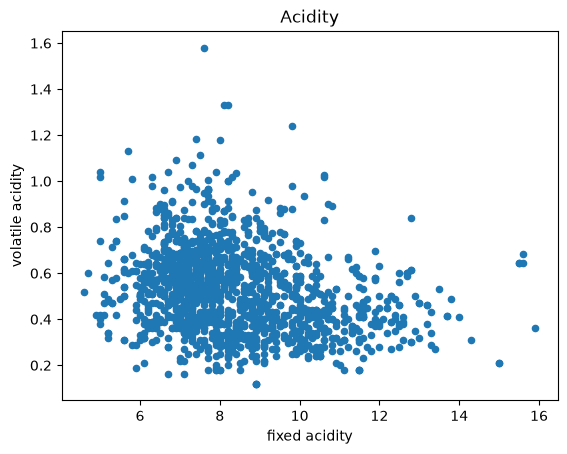

In [67]:
# kind='scatter' cria um grafico de dispersao (scatter plot)
# x e y definem quais colunas serao usadas nos eixos, e 'title' define o titulo do grafico
data.plot(kind='scatter', x='fixed acidity', y='volatile acidity', title='Acidity');

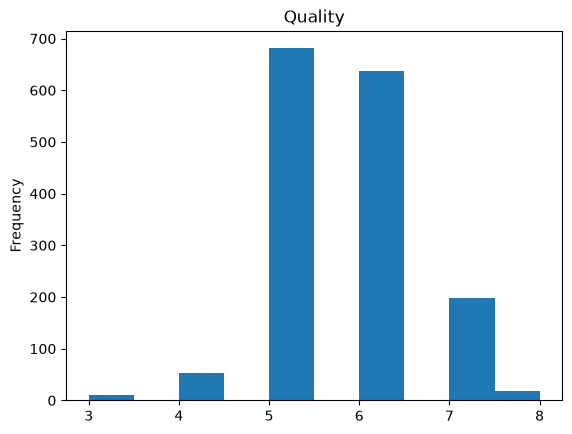

In [68]:
# kind='hist' cria um histograma da coluna selecionada
data['quality'].plot(kind='hist', title='Quality');

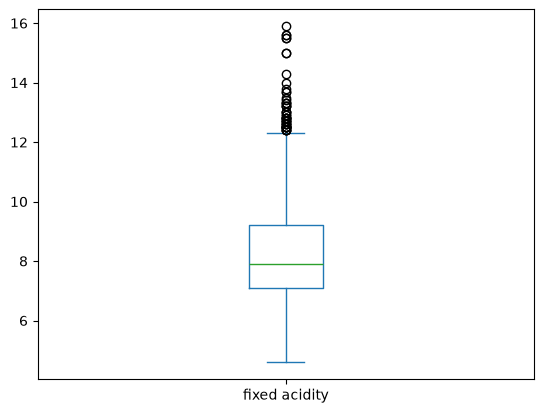

In [69]:
# kind='box' cria um boxplot (diagrama de caixa), util para visualizar a dispersao e outliers
data['fixed acidity'].plot(kind="box");

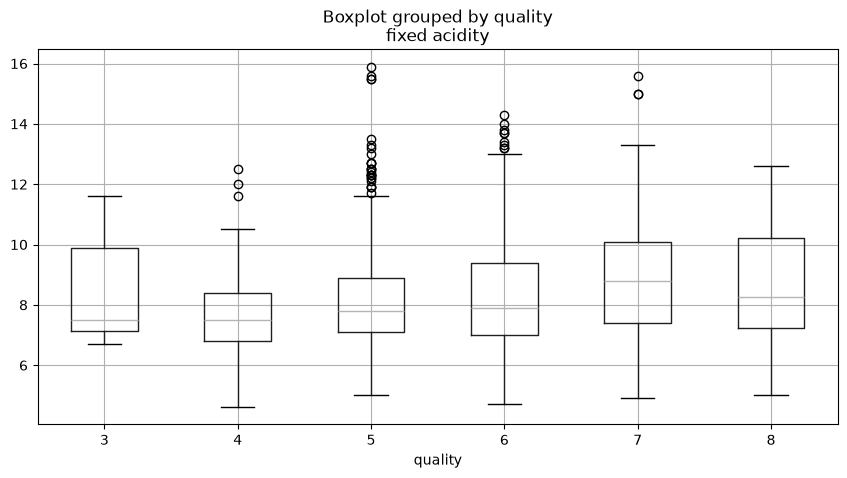

In [70]:
# boxplot() com o parametro 'by' cria um boxplot separado por grupo (aqui, por nivel de 'quality')
# figsize define o tamanho da figura gerada
data.boxplot(column='fixed acidity', by='quality', figsize=(10, 5));

**Leitura adicional:** https://www.learndatasci.com/tutorials/python-pandas-tutorial-complete-introduction-for-beginners/

## 2 - NumPy

**NumPy** (*Numerical Python*) é a biblioteca fundamental para computação
numérica em Python. Ela fornece a estrutura de dados **`ndarray`** (vetor/matriz
multidimensional), que é muito mais rápida e eficiente em memória do que listas
Python comuns, além de oferecer uma enorme quantidade de funções matemáticas
prontas para uso.

A maioria das bibliotecas científicas do Python (Pandas, Matplotlib, SciPy,
scikit-learn etc.) é construída sobre o NumPy.

Leitura complementar: https://cs231n.github.io/python-numpy-tutorial/

Vamos ver, na prática, as operações mais importantes.

### 2.1 - Criando arrays

In [71]:
import numpy as np  # apelido padrao da biblioteca NumPy

# Criando um array a partir de uma lista Python
a = np.array([1, 2, 3, 4, 5])
print("Array a partir de lista:", a)
print("Tipo do objeto:", type(a))

# Criando uma matriz (array 2D) a partir de uma lista de listas
b = np.array([[1, 2, 3], [4, 5, 6]])
print("\nMatriz b:\n", b)

# Atributos uteis de um array:
print("\nFormato (shape) de b:", b.shape)   # (linhas, colunas)
print("Numero de dimensoes de b:", b.ndim)   # 2 (matriz)
print("Tipo dos elementos de b:", b.dtype)   # tipo de dado armazenado (ex: int64)

Array a partir de lista: [1 2 3 4 5]
Tipo do objeto: <class 'numpy.ndarray'>

Matriz b:
 [[1 2 3]
 [4 5 6]]

Formato (shape) de b: (2, 3)
Numero de dimensoes de b: 2
Tipo dos elementos de b: int64


O NumPy também oferece funções prontas para criar arrays especiais, sem precisar digitar todos os valores manualmente:

In [72]:
# np.zeros cria um array preenchido com zeros, com o formato (shape) especificado
zeros = np.zeros((2, 3))
print("Matriz de zeros:\n", zeros)

# np.ones cria um array preenchido com uns
ones = np.ones((3, 2))
print("\nMatriz de uns:\n", ones)

# np.eye cria uma matriz identidade (1's na diagonal, 0's no resto)
identidade = np.eye(3)
print("\nMatriz identidade:\n", identidade)

# np.arange cria uma sequencia de numeros, semelhante ao range() do Python, mas retorna um array
sequencia = np.arange(0, 10, 2)  # inicio=0, fim=10 (exclusive), passo=2
print("\nSequencia com arange:", sequencia)

# np.linspace cria 'num' valores igualmente espacados entre 'start' e 'stop' (inclusive)
linspace = np.linspace(0, 1, 5)  # 5 valores entre 0 e 1
print("Sequencia com linspace:", linspace)

Matriz de zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]

Matriz de uns:
 [[1. 1.]
 [1. 1.]
 [1. 1.]]

Matriz identidade:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Sequencia com arange: [0 2 4 6 8]
Sequencia com linspace: [0.   0.25 0.5  0.75 1.  ]


### 2.2 - Indexação e fatiamento (slicing)

In [73]:
m = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])
print("Matriz m:\n", m)

# Acessando um unico elemento: m[linha, coluna]
print("\nElemento na linha 1, coluna 2:", m[1, 2])

# Fatiamento: selecionando todas as linhas, mas apenas as colunas de indice 1 ate 2
print("\nColunas 1 e 2, todas as linhas:\n", m[:, 1:3])

# Selecionando apenas a primeira linha
print("\nPrimeira linha:", m[0, :])

# Indexacao booleana: seleciona apenas os elementos que satisfazem uma condicao
print("\nElementos maiores que 6:", m[m > 6])

Matriz m:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Elemento na linha 1, coluna 2: 7

Colunas 1 e 2, todas as linhas:
 [[ 2  3]
 [ 6  7]
 [10 11]]

Primeira linha: [1 2 3 4]

Elementos maiores que 6: [ 7  8  9 10 11 12]


### 2.3 - Operações matemáticas com arrays

Uma das grandes vantagens do NumPy é que operações matemáticas são aplicadas
**elemento a elemento** de forma automática (vetorizada), sem a necessidade de laços `for`:

In [74]:
x = np.array([1, 2, 3, 4])
y = np.array([10, 20, 30, 40])

print("Soma:", x + y)          # soma elemento a elemento
print("Subtracao:", y - x)     # subtracao elemento a elemento
print("Multiplicacao:", x * y) # multiplicacao elemento a elemento (NAO e produto matricial)
print("Divisao:", y / x)       # divisao elemento a elemento
print("Potencia:", x ** 2)     # eleva cada elemento ao quadrado

# Funcoes matematicas tambem sao aplicadas elemento a elemento
print("\nRaiz quadrada de x:", np.sqrt(x))
print("Exponencial de x:", np.exp(x))
print("Seno de x:", np.sin(x))

Soma: [11 22 33 44]
Subtracao: [ 9 18 27 36]
Multiplicacao: [ 10  40  90 160]
Divisao: [10. 10. 10. 10.]
Potencia: [ 1  4  9 16]

Raiz quadrada de x: [1.         1.41421356 1.73205081 2.        ]
Exponencial de x: [ 2.71828183  7.3890561  20.08553692 54.59815003]
Seno de x: [ 0.84147098  0.90929743  0.14112001 -0.7568025 ]


Para multiplicação de matrizes (produto matricial de verdade), usamos o operador `@` ou a função `np.dot`:

In [75]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Multiplicacao elemento a elemento (Hadamard)
print("A * B (elemento a elemento):\n", A * B)

# Produto matricial (regras de algebra linear)
print("\nA @ B (produto matricial):\n", A @ B)
print("\nnp.dot(A, B) (equivalente a A @ B):\n", np.dot(A, B))

# Transposta de uma matriz
print("\nTransposta de A:\n", A.T)

A * B (elemento a elemento):
 [[ 5 12]
 [21 32]]

A @ B (produto matricial):
 [[19 22]
 [43 50]]

np.dot(A, B) (equivalente a A @ B):
 [[19 22]
 [43 50]]

Transposta de A:
 [[1 3]
 [2 4]]


### 2.4 - Estatísticas com NumPy

In [76]:
dados = np.array([4, 8, 15, 16, 23, 42])

print("Media:", np.mean(dados))
print("Mediana:", np.median(dados))
print("Desvio padrao:", np.std(dados))
print("Variancia:", np.var(dados))
print("Valor minimo:", np.min(dados))
print("Valor maximo:", np.max(dados))
print("Soma de todos os elementos:", np.sum(dados))

# Em matrizes, podemos calcular estatisticas por linha ou por coluna usando o parametro 'axis'
matriz = np.array([[1, 2, 3], [4, 5, 6]])
print("\nSoma por coluna (axis=0):", np.sum(matriz, axis=0))
print("Soma por linha (axis=1):", np.sum(matriz, axis=1))

Media: 18.0
Mediana: 15.5
Desvio padrao: 12.315302134607444
Variancia: 151.66666666666666
Valor minimo: 4
Valor maximo: 42
Soma de todos os elementos: 108

Soma por coluna (axis=0): [5 7 9]
Soma por linha (axis=1): [ 6 15]


### 2.5 - Números aleatórios

O submódulo `np.random` é muito usado para gerar dados sintéticos, simulações e amostragens:

In [77]:
# Define uma semente (seed) para tornar os resultados aleatorios reproduziveis
np.random.seed(42)

# Numeros aleatorios entre 0 e 1, com distribuicao uniforme
uniforme = np.random.rand(5)
print("Distribuicao uniforme [0,1):", uniforme)

# Numeros aleatorios seguindo uma distribuicao normal (Gaussiana)
# parametros: media (loc), desvio padrao (scale), quantidade de amostras (size)
normal = np.random.normal(loc=0, scale=1, size=5)
print("Distribuicao normal (media=0, desvio=1):", normal)

# Numeros inteiros aleatorios entre um intervalo
inteiros = np.random.randint(low=0, high=10, size=5)
print("Inteiros aleatorios entre 0 e 10:", inteiros)

Distribuicao uniforme [0,1): [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Distribuicao normal (media=0, desvio=1): [ 0.27904129  1.01051528 -0.58087813 -0.52516981 -0.57138017]
Inteiros aleatorios entre 0 e 10: [5 8 0 9 2]


### 2.6 - Reshape (remodelando um array)

In [78]:
# np.arange(12) cria um vetor com 12 elementos (de 0 a 11)
v = np.arange(12)
print("Vetor original:", v)

# reshape() reorganiza os elementos em um novo formato, sem alterar os dados
matriz_3x4 = v.reshape(3, 4)
print("\nRemodelado para 3x4:\n", matriz_3x4)

matriz_2x6 = v.reshape(2, 6)
print("\nRemodelado para 2x6:\n", matriz_2x6)

# flatten() faz o processo inverso: transforma uma matriz de volta em um vetor 1D
print("\nDe volta a 1D (flatten):", matriz_3x4.flatten())

Vetor original: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Remodelado para 3x4:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Remodelado para 2x6:
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]

De volta a 1D (flatten): [ 0  1  2  3  4  5  6  7  8  9 10 11]


## 3 - SciPy

**SciPy** (*Scientific Python*) é construída sobre o NumPy e reúne diversos
módulos para computação científica, como:

- `scipy.stats`      — distribuições de probabilidade e testes estatísticos;
- `scipy.optimize`   — otimização de funções (encontrar mínimos/máximos, ajuste de curvas);
- `scipy.integrate`  — integração numérica e resolução de equações diferenciais;
- `scipy.linalg`     — álgebra linear (mais completa que `numpy.linalg`).

Leitura complementar: https://nbviewer.jupyter.org/github/jrjohansson/scientific-python-lectures/blob/master/Lecture-3-Scipy.ipynb

A seguir, veremos um exemplo prático de cada um desses módulos.

### 3.1 - Estatística (`scipy.stats`)

In [79]:
from scipy import stats  # modulo de estatistica do SciPy
import numpy as np

# Gerando uma amostra de dados com distribuicao normal
np.random.seed(0)
amostra = np.random.normal(loc=10, scale=2, size=200)

# Calculando estatisticas descritivas basicas da amostra
media = np.mean(amostra)
desvio = np.std(amostra)
print(f"Media da amostra: {media:.2f}")
print(f"Desvio padrao da amostra: {desvio:.2f}")

# stats.norm e a distribuicao normal teorica: podemos calcular a densidade de probabilidade (pdf)
# em um ponto especifico, dado uma media (loc) e desvio padrao (scale)
densidade_em_10 = stats.norm.pdf(10, loc=media, scale=desvio)
print(f"Densidade de probabilidade em x=10: {densidade_em_10:.4f}")

# Teste t de uma amostra: verifica se a media da amostra e estatisticamente diferente de um valor de referencia (aqui, 10)
# H0 (hipotese nula): a media da amostra e igual a 10
t_stat, p_valor = stats.ttest_1samp(amostra, popmean=10)
print(f"Estatistica t: {t_stat:.3f}")
print(f"p-valor: {p_valor:.3f}")
if p_valor < 0.05:
    print("Rejeitamos H0: a media e estatisticamente diferente de 10.")
else:
    print("Nao rejeitamos H0: nao ha evidencia suficiente de diferenca em relacao a 10.")

Media da amostra: 10.14
Desvio padrao da amostra: 2.04
Densidade de probabilidade em x=10: 0.1948
Estatistica t: 0.979
p-valor: 0.329
Nao rejeitamos H0: nao ha evidencia suficiente de diferenca em relacao a 10.


### 3.2 - Otimização (`scipy.optimize`)

Podemos usar o SciPy para encontrar o valor de `x` que minimiza uma função matemática:

In [80]:
from scipy import optimize
import numpy as np

# Definimos uma funcao que queremos minimizar: f(x) = (x - 3)^2 + 5
# O minimo dessa funcao ocorre, obviamente, em x = 3 (onde o valor e 5)
def f(x):
    return (x - 3) ** 2 + 5

# optimize.minimize_scalar busca o valor de x que minimiza f(x)
resultado = optimize.minimize_scalar(f)

print("Valor de x que minimiza f(x):", resultado.x)
print("Valor minimo de f(x):", resultado.fun)

Valor de x que minimiza f(x): 3.0000000000000004
Valor minimo de f(x): 5.0


O SciPy também permite ajustar (fazer *fit* de) uma curva a um conjunto de pontos experimentais:

In [81]:
from scipy.optimize import curve_fit
import numpy as np

# Definimos o modelo teorico que queremos ajustar aos dados: uma reta y = a*x + b
def modelo_linear(x, a, b):
    return a * x + b

# Gerando dados simulados com ruido, a partir de uma reta conhecida (a=2, b=1)
np.random.seed(1)
x_dados = np.linspace(0, 10, 50)
y_dados = 2 * x_dados + 1 + np.random.normal(0, 1, size=x_dados.shape)  # adiciona ruido aleatorio

# curve_fit encontra os parametros (a, b) que melhor ajustam o modelo aos dados
parametros_otimos, _ = curve_fit(modelo_linear, x_dados, y_dados)

a_estimado, b_estimado = parametros_otimos
print(f"Parametros estimados: a = {a_estimado:.2f}, b = {b_estimado:.2f}")
print("(Os valores reais usados para gerar os dados foram a=2 e b=1)")

Parametros estimados: a = 2.04, b = 0.77
(Os valores reais usados para gerar os dados foram a=2 e b=1)


### 3.3 - Integração numérica (`scipy.integrate`)

In [82]:
from scipy import integrate
import numpy as np

# Vamos calcular a integral definida da funcao f(x) = x^2 no intervalo [0, 1]
# O resultado teorico (analitico) e 1/3 = 0.333...
def f(x):
    return x ** 2

# integrate.quad calcula a integral definida e retorna (valor, erro_estimado)
valor_integral, erro_estimado = integrate.quad(f, 0, 1)

print(f"Valor da integral (numerico): {valor_integral:.5f}")
print(f"Erro estimado: {erro_estimado:.2e}")
print("Valor teorico esperado: 0.33333")

Valor da integral (numerico): 0.33333
Erro estimado: 3.70e-15
Valor teorico esperado: 0.33333


### 3.4 - Álgebra linear (`scipy.linalg`)

In [83]:
from scipy import linalg
import numpy as np

# Matriz de exemplo
M = np.array([[2, 1], [1, 3]])

# Calculando o determinante da matriz
det_M = linalg.det(M)
print("Determinante de M:", det_M)

# Calculando a matriz inversa
inv_M = linalg.inv(M)
print("Matriz inversa de M:\n", inv_M)

# Resolvendo o sistema linear M @ x = b, ou seja, encontrando o vetor x
b = np.array([5, 10])
x_solucao = linalg.solve(M, b)
print("Solucao do sistema M @ x = b:", x_solucao)

# Calculando autovalores e autovetores de M
autovalores, autovetores = linalg.eig(M)
print("Autovalores de M:", autovalores.real)
print("Autovetores de M:")
print(autovetores)

Determinante de M: 5.0
Matriz inversa de M:
 [[ 0.6 -0.2]
 [-0.2  0.4]]
Solucao do sistema M @ x = b: [1. 3.]
Autovalores de M: [1.38196601 3.61803399]
Autovetores de M:
[[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


## 4 - Matplotlib

**Matplotlib** é a biblioteca mais tradicional do Python para criação de
gráficos e visualizações de dados. Ela oferece controle detalhado sobre cada
elemento do gráfico (eixos, cores, legendas, títulos etc.) e serve de base
para outras bibliotecas de visualização, como Seaborn e a própria Pandas.

Vamos explorar, passo a passo, os principais tipos de gráficos.

### 4.1 - Gráfico de linha simples

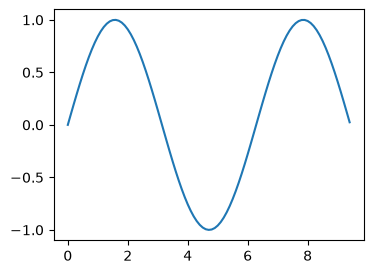

In [84]:
import numpy as np
import matplotlib.pyplot as plt  # apelido padrao do modulo pyplot do Matplotlib

# Calcula as coordenadas x e y de pontos sobre uma curva senoidal
x = np.arange(0, 3 * np.pi, 0.1)  # valores de x, de 0 ate 3*pi, em passos de 0.1
y = np.sin(x)                     # aplica a funcao seno a cada valor de x

# Cria a figura com um tamanho especifico (largura=8, altura=4 polegadas)
plt.figure(figsize=(4, 3))

# Desenha a curva (x, y)
plt.plot(x, y)

# Exibe o grafico na tela (obrigatorio fora de notebooks; em notebooks e opcional, mas boa pratica)
plt.show()

### 4.2 - Múltiplas curvas no mesmo gráfico, com legenda

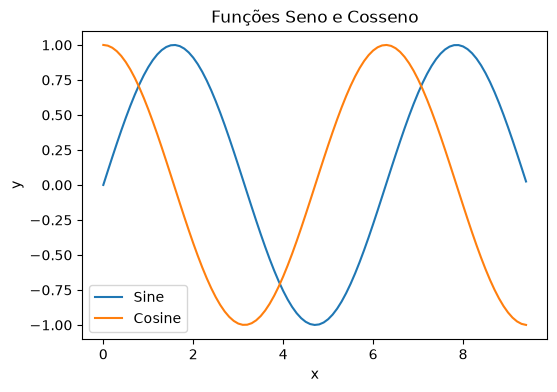

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Calcula as coordenadas para as curvas de seno e cosseno
x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure(figsize=(6, 4))

# label define o nome que aparecera na legenda de cada curva
plt.plot(x, y_sin, label='Sine')
plt.plot(x, y_cos, label='Cosine')

# plt.legend() exibe a legenda com os rotulos (labels) definidos acima
plt.legend()

# Adiciona titulo e rotulos aos eixos, para deixar o grafico mais informativo
plt.title('Funções Seno e Cosseno')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

### 4.3 - Estilos de linha diferentes

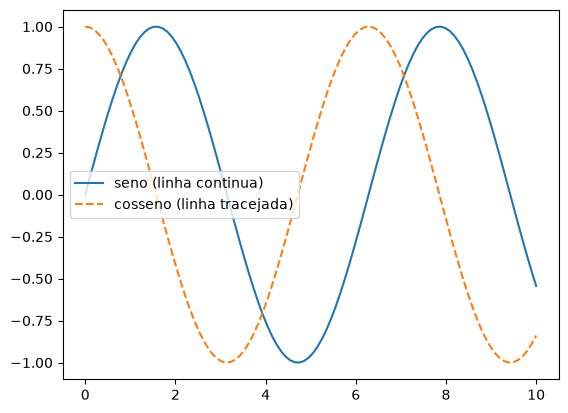

In [86]:
import numpy as np

x = np.linspace(0, 10, 100)  # 100 pontos igualmente espacados entre 0 e 10

fig = plt.figure()

# '-' desenha uma linha continua; '--' desenha uma linha tracejada
plt.plot(x, np.sin(x), '-', label='seno (linha continua)')
plt.plot(x, np.cos(x), '--', label='cosseno (linha tracejada)')
plt.legend()
plt.show()

### 4.4 - Salvando um gráfico em arquivo

In [90]:
# fig.savefig() salva a ULTIMA figura criada (armazenada na variavel 'fig') em um arquivo
# O formato do arquivo (PDF, PNG, etc.) e definido automaticamente pela extensao do nome do arquivo
fig.savefig("fig/filename.pdf")
print("Figura salva como 'filename.pdf' no diretorio /fig/.")

Figura salva como 'filename.pdf' no diretorio /fig/.


### 4.5 - Subplots (múltiplos gráficos na mesma figura)

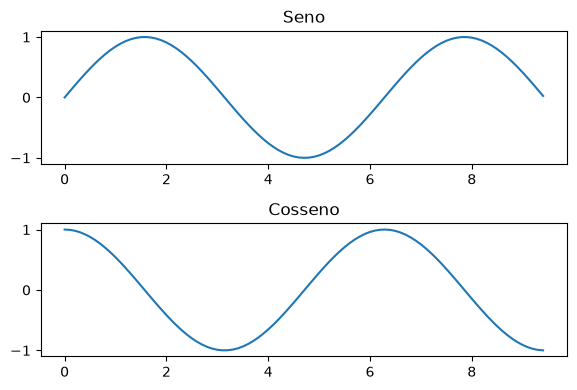

In [88]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)

# plt.figure define o tamanho total da figura que ira conter os subplots
plt.figure(figsize=(6, 4))

# plt.subplot(linhas, colunas, indice_do_subplot_atual)
# Aqui criamos uma grade de 2 linhas x 1 coluna, e ativamos o primeiro subplot (indice 1)
plt.subplot(2, 1, 1)
plt.plot(x, y_sin)
plt.title('Seno')

# Ativa o segundo subplot (indice 2) da mesma grade 2x1
plt.subplot(2, 1, 2)
plt.plot(x, y_cos)
plt.title('Cosseno')

# tight_layout ajusta automaticamente os espacos entre os subplots, evitando sobreposicoes
plt.tight_layout()
plt.show()

### 4.6 - Lendo e exibindo uma imagem

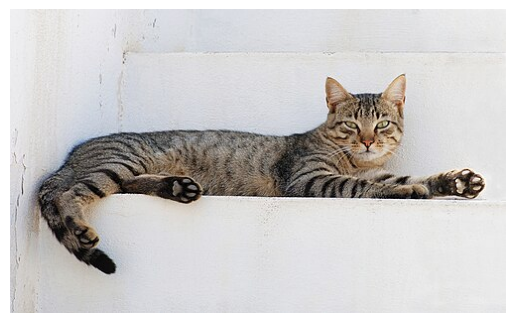

In [93]:
import matplotlib.pyplot as plt

# plt.imread le uma imagem do disco e a converte em um array NumPy (altura x largura x canais de cor)
image = plt.imread(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\cat.jpg')
# plt.imshow exibe o array como uma imagem
plt.imshow(image)
plt.axis('off')  # remove os eixos (numeros e marcacoes), pois nao fazem sentido para uma imagem
plt.show()

### 4.7 - Gráfico de dispersão (scatter plot)

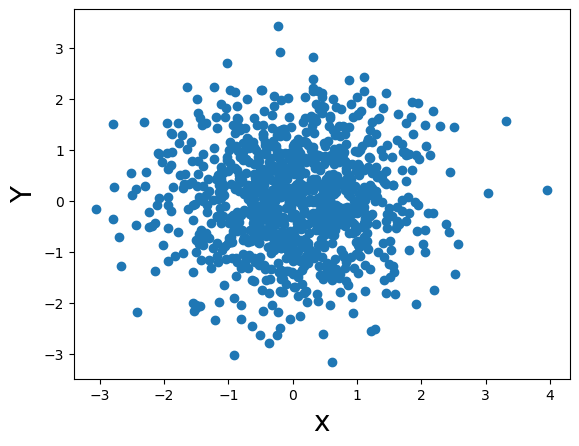

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 1000
# Gera duas variaveis aleatorias independentes, seguindo distribuicao normal padrao
X = np.random.normal(0, 1, n)
Y = np.random.normal(0, 1, n)

plt.xlabel("x", fontsize=20)
plt.ylabel("Y", fontsize=20)

# scatter cria um grafico de dispersao: cada ponto (X[i], Y[i]) e desenhado individualmente
plt.scatter(X, Y)
plt.show()

### 4.8 - Gráfico de barras

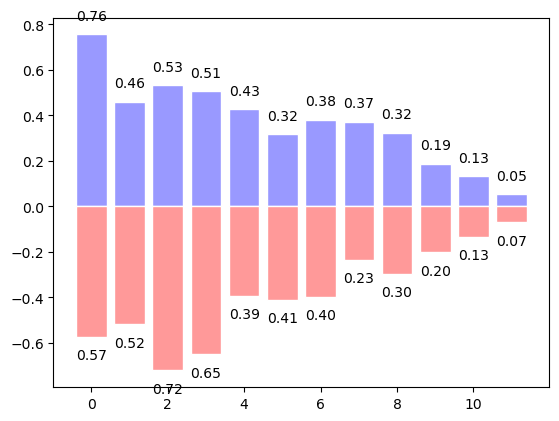

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 12
X = np.arange(n)  # posicoes das barras no eixo x: 0, 1, 2, ..., 11

# Gera valores aleatorios para duas series de barras
Y1 = (1 - X / float(n)) * np.random.uniform(0.5, 1.0, n)
Y2 = (1 - X / float(n)) * np.random.uniform(0.5, 1.0, n)

# Barras positivas (para cima), em azul claro
plt.bar(X, +Y1, facecolor='#9999ff', edgecolor='white')

# Barras negativas (para baixo), em vermelho claro
plt.bar(X, -Y2, facecolor='#ff9999', edgecolor='white')

# Adiciona o valor numerico de cada barra de Y1, logo acima dela
for x, y in zip(X, Y1):
    plt.text(x + 0.0, y + 0.05, '%.2f' % y, ha='center', va='bottom')

# Adiciona o valor numerico de cada barra de Y2, logo abaixo dela
for x, y in zip(X, Y2):
    plt.text(x + 0.0, -y - 0.05, '%.2f' % y, ha='center', va='top')

plt.show()

### 4.9 - Gráfico de contorno (contour plot)

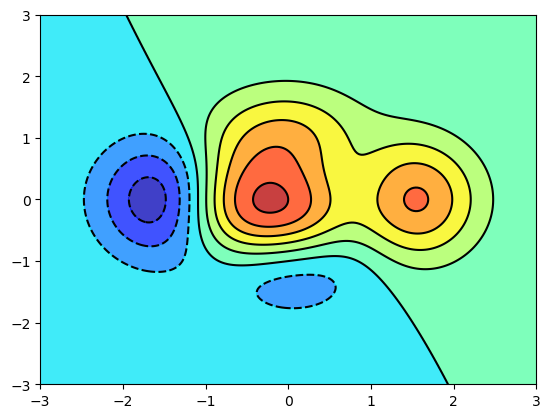

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define uma funcao de duas variaveis f(x, y)
def f(x, y):
    return (1 - x / 2 + x ** 5 + y ** 3) * np.exp(-x ** 2 - y ** 2)

n = 256
x = np.linspace(-3, 3, n)
y = np.linspace(-3, 3, n)

# meshgrid cria duas matrizes 2D (X, Y) que representam todas as combinacoes de x e y
# isso permite calcular f(X, Y) para toda a grade de pontos de uma so vez
X, Y = np.meshgrid(x, y)

# contourf desenha regioes de contorno PREENCHIDAS (coloridas), com 8 niveis, usando o mapa de cores 'jet'
plt.contourf(X, Y, f(X, Y), 8, alpha=.75, cmap='jet')

# contour desenha apenas as LINHAS de contorno (sem preenchimento), na cor preta
plt.contour(X, Y, f(X, Y), 8, colors='black')

plt.show()

### 4.10 - Gráfico de pizza (pie chart)

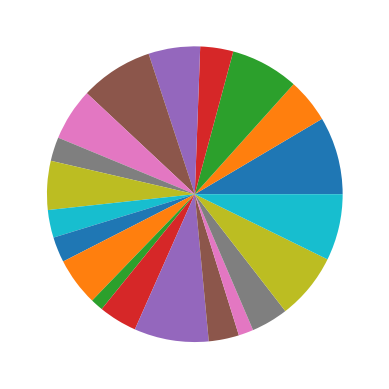

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gera 20 valores aleatorios entre 0 e 1, que representarao as fatias da pizza
Z = np.random.uniform(0, 1, 20)

# plt.pie desenha o grafico de pizza: cada valor de Z vira uma fatia proporcional ao seu tamanho
plt.pie(Z)
plt.show()

### 4.11 - Gráfico de superfície 3D

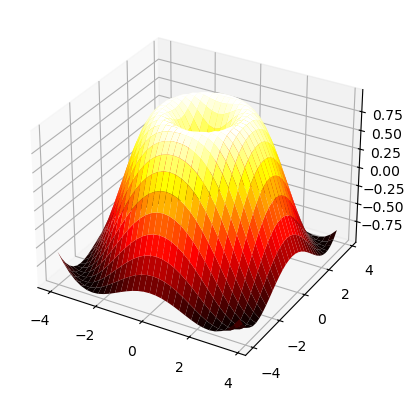

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessario para habilitar projecoes 3D

fig = plt.figure()

# Cria um sistema de eixos com projecao 3D
ax = fig.add_subplot(111, projection='3d')

X = np.arange(-4, 4, 0.25)
Y = np.arange(-4, 4, 0.25)

# Cria a grade 2D de coordenadas (X, Y) para calcular Z em cada ponto
X, Y = np.meshgrid(X, Y)

# Calcula a distancia radial R e a altura Z = sin(R), gerando um padrao de ondas concentricas
R = np.sqrt(X ** 2 + Y ** 2)
Z = np.sin(R)

# plot_surface desenha a superficie 3D
# rstride/cstride controlam a resolucao da malha desenhada; cmap define o mapa de cores
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='hot')

plt.show()

### 4.12 - Histogramas

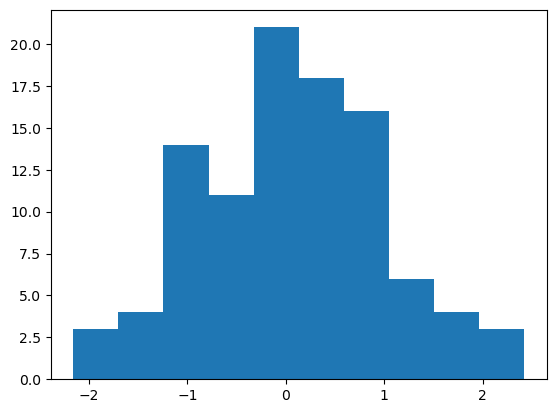

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gera 100 numeros aleatorios com distribuicao normal padrao
data = np.random.randn(100)

# plt.hist cria um histograma, agrupando os dados em faixas (bins) e contando a frequencia em cada uma
plt.hist(data)
plt.show()

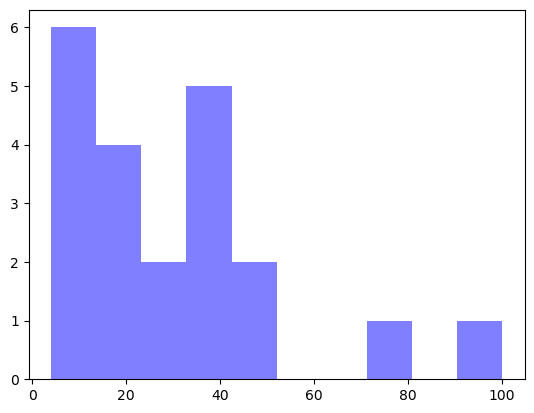

In [ ]:
x = [21, 22, 23, 4, 5, 6, 77, 8, 9, 10, 31, 32, 33, 34, 35, 36, 37, 18, 49, 50, 100]

num_bins = 10  # numero de faixas (bins) do histograma

# n: quantidade de valores em cada bin
# bins: os limites de cada bin
# patches: os objetos graficos (retangulos) desenhados
n, bins, patches = plt.hist(x, num_bins, facecolor='blue', alpha=0.5, )  # alpha define a transparencia
plt.show()

O parâmetro `bins='auto'` permite que o próprio Matplotlib escolha automaticamente o número ideal de faixas:

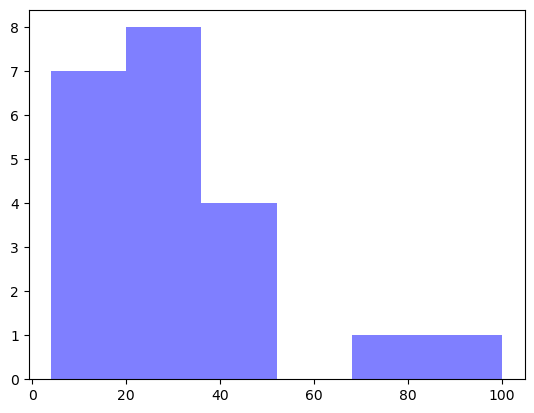

In [ ]:
# bins='auto' deixa o Matplotlib decidir a melhor quantidade de faixas com base nos dados
n, bins, patches = plt.hist(x, bins='auto', facecolor='blue', alpha=0.5)
plt.show()

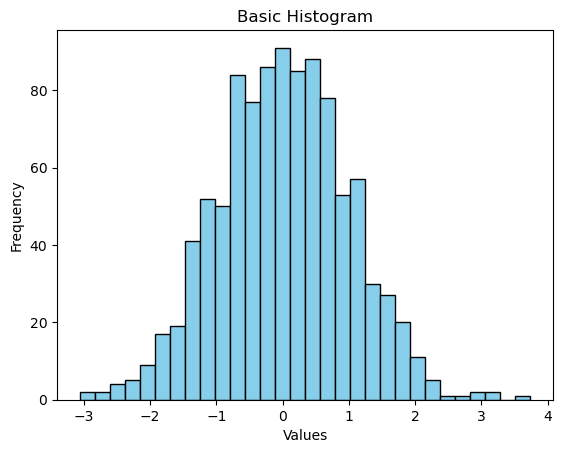

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random data for the histogram
data = np.random.randn(1000)

# Plotting a basic histogram
plt.hist(data, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram')

# Display the plot
plt.show()

Também podemos sobrepor múltiplos histogramas no mesmo gráfico para compará-los:

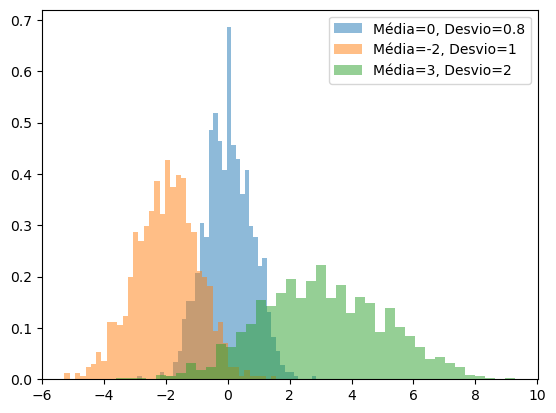

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gera tres amostras com distribuicoes normais diferentes (medias e desvios distintos)
x1 = np.random.normal(0, 0.8, 1000)   # media=0, desvio=0.8
x2 = np.random.normal(-2, 1, 1000)    # media=-2, desvio=1
x3 = np.random.normal(3, 2, 1000)     # media=3, desvio=2

# Definimos um dicionario de argumentos comuns para reutilizar nos tres histogramas:
#   histtype='stepfilled' : desenha o histograma como uma area preenchida com contorno
#   alpha=0.5              : transparencia, para permitir ver a sobreposicao das distribuicoes
#   density=True           : normaliza o histograma para que a area total seja 1 (vira uma densidade)
#   bins=40                : numero de faixas
kwargs = dict(histtype='stepfilled', alpha=0.5, density=True, bins=40)

plt.hist(x1, **kwargs, label='Média=0, Desvio=0.8')
plt.hist(x2, **kwargs, label='Média=-2, Desvio=1')
plt.hist(x3, **kwargs, label='Média=3, Desvio=2')

plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random data for stacked histograms
data1 = np.random.randn(1000)
data2 = np.random.normal(loc=3, scale=1, size=1000)

# Creating a stacked histogram
plt.hist([data1, data2], bins=30, stacked=True, color=['cyan', 'Purple'], edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Stacked Histogram')

# Adding legend
plt.legend(['Dataset 1', 'Dataset 2'])

# Display the plot
plt.show()

Histograma com estimação da densidade.

/Users/franciscoaparecidorodrigues/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


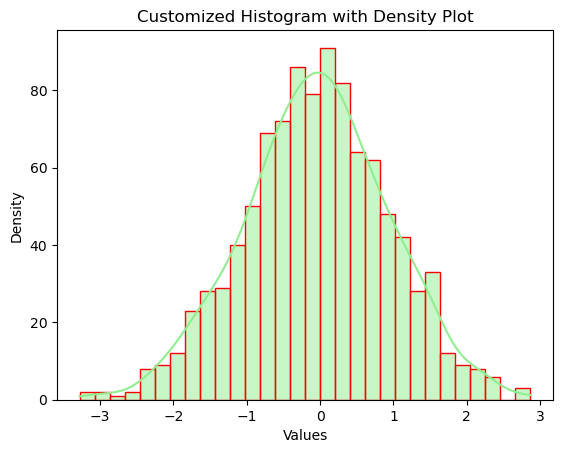

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate random data for the histogram
data = np.random.randn(1000)

# Creating a customized histogram with a density plot
sns.histplot(data, bins=30, kde=True, color='lightgreen', edgecolor='red')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Customized Histogram with Density Plot')

# Display the plot
plt.show()

---

## Exercícios

1 - Leia os dados da base Vehicle.csv e elimine as duas primeiras colunas.

2 - Mostre o histograma do quinto atributo.

3 - Em um mesmo plot, mostre os gráficos da funções: $y = x^2 + 2$ e $y = 3*cos(x) + exp(x)$. Defina o intervalo [-10,10].

4 - Na curva 3D acima, troque a função seno pela cosseno.

5 - Gere dois vetores de acordo com uma distribuição uniforme e mostre os resultados. Crie 100 observações de cada variável.